In [22]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import os
os.makedirs('../reports/charts',exist_ok=True)
df = pd.read_csv('../data/superstore_clean.csv')

In [7]:
total_sales = df['Sales'].sum().round(2)

In [8]:
print(total_sales)

2296195.59


In [9]:
total_profit = df['Profit'].sum().round(2)
print(total_profit)

286241.42


In [11]:
category_sales = df.groupby("Category")['Sales'].sum().round(2)
category_sales

Category
Furniture          741306.31
Office Supplies    718735.24
Technology         836154.03
Name: Sales, dtype: float64

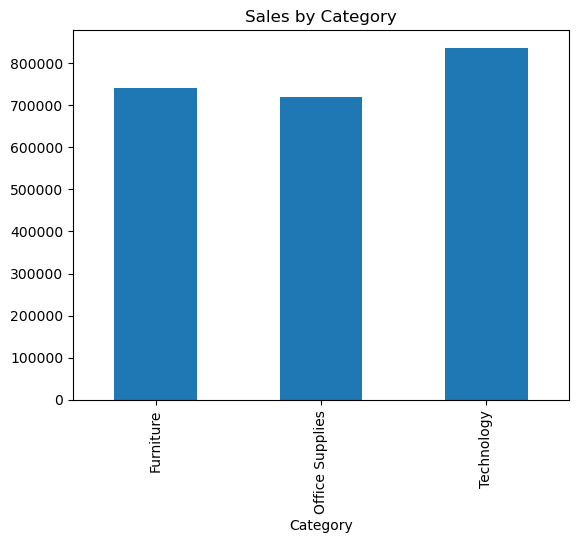

In [26]:
category_sales.plot(kind="bar", title="Sales by Category")
plt.savefig('../reports/charts/sale_category.png',dpi=300)
plt.show()

In [13]:
region_profit = df.groupby('Region')['Profit'].sum().round(2)
region_profit

Region
Central     39655.88
East        91506.31
South       46749.43
West       108329.81
Name: Profit, dtype: float64

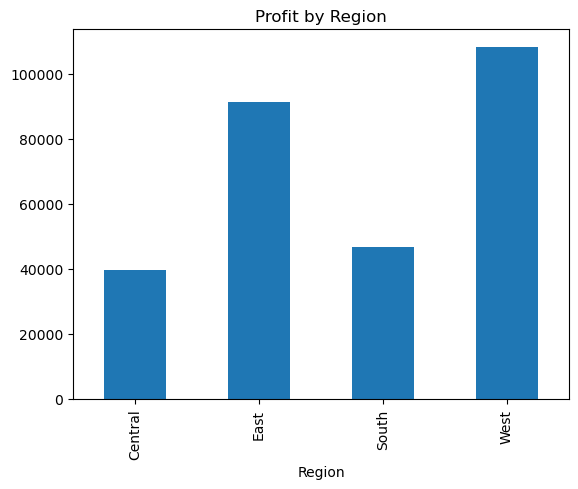

In [27]:
region_profit.plot(kind='bar', title='Profit by Region')
plt.savefig('../reports/charts/profit_region.png',dpi=300)
plt.show()

In [17]:
top_products = (df.groupby('Sub-Category')['Sales'].sum().round(2).sort_values(ascending=False).head(10))
top_products

Sub-Category
Phones         330007.05
Chairs         327777.76
Storage        223843.61
Tables         206965.53
Binders        203409.17
Machines       189238.63
Accessories    167380.32
Copiers        149528.03
Bookcases      114880.00
Appliances     107532.16
Name: Sales, dtype: float64

In [18]:
df['Profit Status'].value_counts()

Profit Status
Profit    8108
Loss      1869
Name: count, dtype: int64

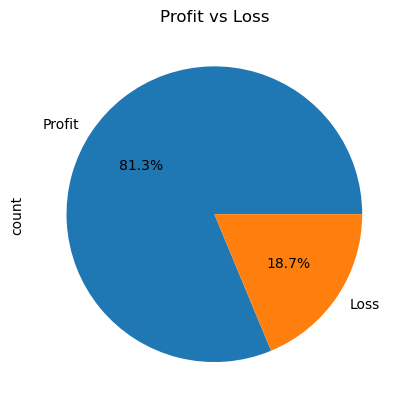

In [28]:
df['Profit Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Profit vs Loss')
plt.savefig('../reports/charts/profit_loss.png',dpi=300)
plt.show()

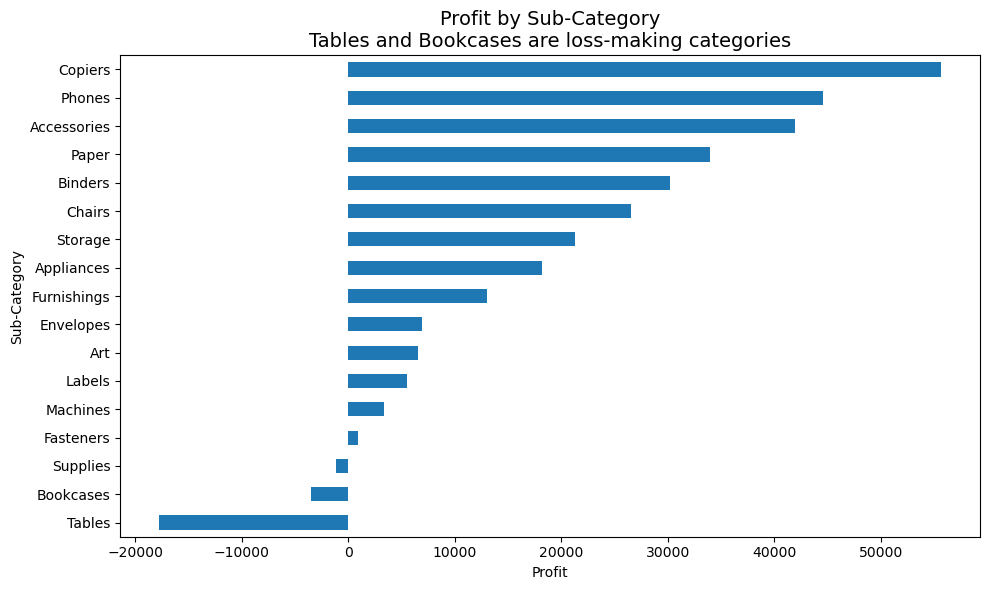

In [29]:
profit_sub = (df.groupby('Sub-Category')['Profit'].sum().sort_values())
plt.figure(figsize=(10,6))
profit_sub.plot(kind='barh')
plt.title("Profit by Sub-Category\nTables and Bookcases are loss-making categories",fontsize=14)
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.savefig('../reports/charts/profit_subcategory.png',dpi=300)
plt.show()

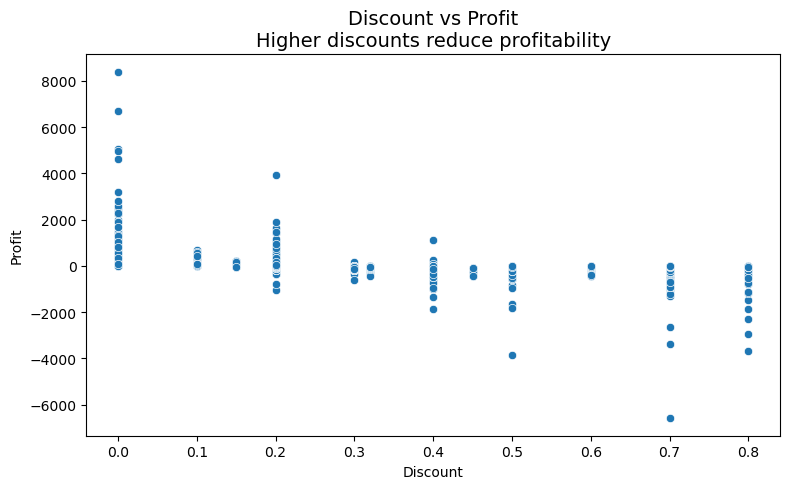

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Discount vs Profit\nHigher discounts reduce profitability',fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.savefig('../reports/charts/discount_profit.png',dpi=300)
plt.show()

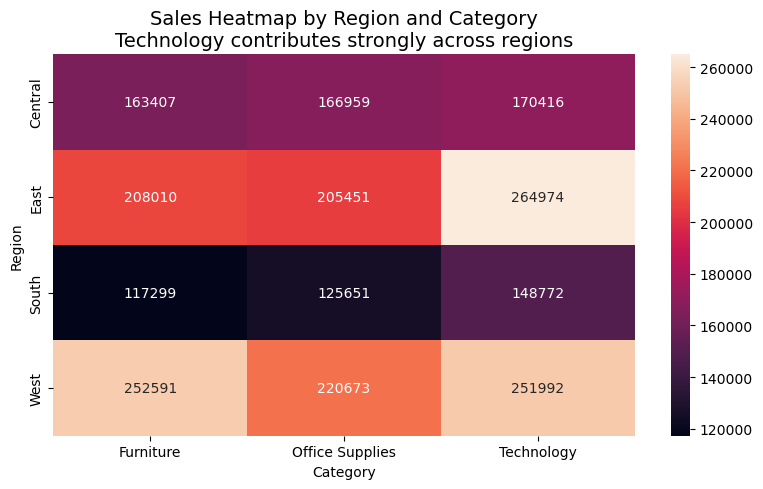

In [31]:
heatmap_data = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')
plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f')
plt.title('Sales Heatmap by Region and Category\nTechnology contributes strongly across regions', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/charts/region_category_heatmap.png',dpi=300)
plt.show()